#  Unsupervised Learning (E-Commerce Orders)

- Perform **clustering** to identify similar order types
- Apply **market basket analysis** (association rule mining)
- Write up findings throughout the notebook
- Publish your analysis as a github.io page

Work **top-to-bottom**. Complete each task in order before moving on.

## Setup

Run the cell below to import the required Python packages.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

plt.style.use('seaborn-v0_8')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## Load Your Cleaned Dataset from Assignment 1

Load the cleaned and expanded dataset you created in Assignment 1 (and potentially modified in Assignment 2).

In [18]:
# ANSWER: Load your cleaned dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ecommerce_orders_cleaned_Grp11.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (46287, 17)

Columns: ['order_id', 'order_status', 'order_purchase_hour', 'order_purchase_dayofweek', 'order_purchase_month', 'order_total_value', 'num_items', 'num_unique_products', 'num_unique_sellers', 'total_item_price', 'avg_item_price', 'total_freight_value', 'top_product_category', 'customer_state', 'payment_type', 'order_value_per_item', 'order_size_category']


,order_id,order_status,order_purchase_hour,order_purchase_dayofweek,order_purchase_month,order_total_value,num_items,num_unique_products,num_unique_sellers,total_item_price,avg_item_price,total_freight_value,top_product_category,customer_state,payment_type,order_value_per_item,order_size_category
0,sdv-id-whzjUX,shipped,10,4,4,744.312535,1,1,1,352.420029,369.966521,68.790159,construction_tools_construction,Massachusetts,voucher,352.420029,Small
1,sdv-id-dbopoJ,delivered,19,2,3,1556.667902,1,1,1,289.242639,1354.621410,15.394619,health_beauty,Vermont,credit_card,289.242639,Small
2,sdv-id-FSEOvM,delivered,15,4,8,62.060506,1,1,1,26.893468,48.485654,18.751282,luggage_accessories,South Carolina,debit_card,26.893468,Small
3,sdv-id-bQcBUR,delivered,21,0,8,73.873470,1,1,1,37.790896,75.704909,8.670875,computers_accessories,Kentucky,credit_card,37.790896,Small
4,sdv-id-MPxIXB,delivered,13,5,5,361.961537,3,3,3,169.528323,50.132979,34.731146,pet_shop,Missouri,voucher,56.509441,Medium


In [19]:
!jupyter nbconvert --to html "/content/drive/MyDrive/5100FProjSubmission/IT5100F_A3_11.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/5100FProjSubmission/IT5100F_A3_11.ipynb to html
[NbConvertApp] Writing 381467 bytes to /content/drive/MyDrive/5100FProjSubmission/IT5100F_A3_11.html


## Load data
Load the cleaned and processed dataset from Assignment 1 (46,287 orders, 17 columns) is loaded with engineered features (order_value_per_item, order_size_category).

---
## Task: Unsupervised Learning

### Objective

In this task, you will work on unsupervised learning and support your analysis with visualization. Perform clustering to identify **similar orders** and generate **order type recommendations** based on their characteristics. An order type cluster represents a group of orders with similar purchasing patterns, value structures, and composition.

### 1: Data Preprocessing for Unsupervised Learning [1 Mark]

Goal: Create DataFrames that contain one row per order with features suitable for both clustering and association mining.

#### 1.1 Create `all_orders_df` (one row per order)

Create a new DataFrame called `all_orders_df` with the following columns:

Identifier:
- `order_id` — Unique identifier of the order
- `basket_size` — Monetary value of the order (from `order_total_value`)
- `basket_qty` — Number of items in the order (from `num_items`)
- `freight_ratio` — Proportion of the order value that is freight (computed as `total_freight_value / order_total_value`)
- `product_diversity` — How varied the basket is in terms of product types (computed as `num_unique_products / num_items`)
- `top_product_category` — The dominant product category in the order
- `payment_type` — The payment method used
- `order_size_category` — The order size category (Small/Medium/Large)

Notes:
- `all_orders_df` must have exactly one row per `order_id`.
- No missing values should remain in these columns after preprocessing (apply reasonable handling if needed).
- Handle potential division issues appropriately (e.g., orders with zero values).
- Display the first 10 rows of `all_orders_df`, its shape, and data types.


In [20]:
# 1.1 ANSWER: Create all_orders_df

all_orders_df = df[['order_id']].copy()
all_orders_df['basket_size'] = df['order_total_value'].values
all_orders_df['basket_qty'] = df['num_items'].values

# Zero value Error handling
all_orders_df['freight_ratio'] = np.where(
    df['order_total_value'] > 0,
    df['total_freight_value'] / df['order_total_value'],
    0
)

all_orders_df['product_diversity'] = np.where(
    df['num_items'] > 0,
    df['num_unique_products'] / df['num_items'],
    0
)

# Categorical
all_orders_df['top_product_category'] = df['top_product_category'].values
all_orders_df['payment_type'] = df['payment_type'].values
all_orders_df['order_size_category'] = df['order_size_category'].values

# Missing values
all_orders_df['freight_ratio'] = all_orders_df['freight_ratio'].fillna(0)
all_orders_df['product_diversity'] = all_orders_df['product_diversity'].fillna(0)
all_orders_df['top_product_category'] = all_orders_df['top_product_category'].fillna(all_orders_df['top_product_category'].mode()[0])
all_orders_df['payment_type'] = all_orders_df['payment_type'].fillna(all_orders_df['payment_type'].mode()[0])
all_orders_df['order_size_category'] = all_orders_df['order_size_category'].fillna(all_orders_df['order_size_category'].mode()[0])

# Display results
print("First 10 rows of all_orders_df:")
display(all_orders_df.head(10))
print(f"\nShape: {all_orders_df.shape}")
print(f"\nData types:\n{all_orders_df.dtypes}")


First 10 rows of all_orders_df:


,order_id,basket_size,basket_qty,freight_ratio,product_diversity,top_product_category,payment_type,order_size_category
0,sdv-id-whzjUX,744.312535,1,0.092421,1.000000,construction_tools_construction,voucher,Small
1,sdv-id-dbopoJ,1556.667902,1,0.009889,1.000000,health_beauty,credit_card,Small
2,sdv-id-FSEOvM,62.060506,1,0.302145,1.000000,luggage_accessories,debit_card,Small
3,sdv-id-bQcBUR,73.873470,1,0.117375,1.000000,computers_accessories,credit_card,Small
4,sdv-id-MPxIXB,361.961537,3,0.095953,1.000000,pet_shop,voucher,Medium
5,sdv-id-ySodbB,867.750230,7,0.204442,0.857143,sports_leisure,voucher,Large
6,sdv-id-wdwBrk,55.965822,2,0.285101,0.500000,toys,points,Small
7,sdv-id-maBYtk,170.295452,3,0.089290,1.000000,computers_accessories,voucher,Medium
8,sdv-id-oodUXj,83.065603,1,0.236471,1.000000,furniture_decor,voucher,Small
9,sdv-id-zroJIL,98.250248,1,0.369709,1.000000,fashion_bags_accessories,points,Small



Shape: (46287, 8)

Data types:
order_id                 object
basket_size             float64
basket_qty                int64
freight_ratio           float64
product_diversity       float64
top_product_category     object
payment_type             object
order_size_category      object
dtype: object


## Further feature engineering
These four features capture an order's monetary value, volume, shipping cost proportion, and product variety. Division-by-zero is handled explicitly before computing ratios.

#### 1.2 Create `orders_analysis_df`

- Use `train_test_split` from sklearn to split the data in `all_orders_df`.
- Set `test_size=0.3` (keep 30% of data for analysis) and `random_state=37` for reproducibility.
- Assign the **test set** to the variable `orders_analysis_df`.

Display the shape of `orders_analysis_df` and show its first 10 rows.


In [21]:
# 1.2 ANSWER: Create orders_analysis_df using train_test_split

_, orders_analysis_df = train_test_split(all_orders_df, test_size=0.3, random_state=37)

print(f"Shape of orders_analysis_df: {orders_analysis_df.shape}")
print(f"\nFirst 10 rows:")
display(orders_analysis_df.head(10))


Shape of orders_analysis_df: (13887, 8)

First 10 rows:


,order_id,basket_size,basket_qty,freight_ratio,product_diversity,top_product_category,payment_type,order_size_category
1882,sdv-id-ISddRn,132.611695,1,0.126285,1.000000,christmas_supplies,voucher,Small
40995,sdv-id-GmlErp,730.510053,6,0.075288,0.666667,furniture_decor,credit_card,Large
40104,sdv-id-BWpket,632.486142,1,0.051262,1.000000,bed_bath_table,credit_card,Small
25808,sdv-id-krmbPT,47.102393,1,0.248932,1.000000,telephony,credit_card,Small
23294,sdv-id-vhfMmG,133.285008,1,0.135860,1.000000,health_beauty,debit_card,Small
7160,sdv-id-kcTYfM,403.696187,2,0.079065,0.500000,auto,credit_card,Small
7180,sdv-id-tFFFCg,211.465148,2,0.162263,1.000000,furniture_decor,voucher,Small
20801,sdv-id-KgDKAA,57.520738,1,0.228879,1.000000,bed_bath_table,credit_card,Small
19879,sdv-id-cfCjEB,576.212699,3,0.056350,0.666667,bed_bath_table,credit_card,Medium
39874,sdv-id-uxRZME,141.772602,2,0.200719,1.000000,fashion_bags_accessories,credit_card,Small


## Stratified sampling for Elbow method testing
`orders_analysis_df` (30% of all orders) provides a representative random sample to run the Elbow Method (k=3 to 9) without repeatedly fitting K-Means on all 46,287 orders. The full `all_orders_df` is then used in Task 3 to assign every order a final cluster

### 2: Determine the Optimal Number of Clusters [3 Marks]

#### 2.1 Run K-Means for Different Cluster Numbers

- Use **only the four numerical features** from `orders_analysis_df` (`basket_size`, `basket_qty`, `freight_ratio`, `product_diversity`) for clustering.
- Run K-means clustering from **k = 3 to 9** clusters.
- Important: First scale the numerical features using `StandardScaler` before fitting K-means.
- In each run, calculate the **inertia** of the cluster and store the values for each k (3 to 9) in a list or table.

Inertia is a measure of how tightly packed the clusters are. It is the sum of squared distances between each point and its assigned cluster center (centroid). Lower inertia indicates that the clusters are more compact, and the points are closer to their centroids, suggesting better clustering.


In [22]:
# 2.1 ANSWER: Run K-means for k=3 to 9 and calculate inertia

numerical_features = ['basket_size', 'basket_qty', 'freight_ratio', 'product_diversity']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(orders_analysis_df[numerical_features])

# Run K-means for k = 3 to 9
k_range = range(3, 10)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=37, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k = {k}: Inertia = {kmeans.inertia_:.2f}")

# Store in a DataFrame for easy reference
inertia_df = pd.DataFrame({'k': list(k_range), 'inertia': inertias})
display(inertia_df)


k = 3: Inertia = 28884.29
k = 4: Inertia = 21464.39
k = 5: Inertia = 17303.04
k = 6: Inertia = 15013.97
k = 7: Inertia = 13219.44
k = 8: Inertia = 11762.79
k = 9: Inertia = 10516.16


,k,inertia
0,3,28884.287460
1,4,21464.393895
2,5,17303.035640
3,6,15013.968444
4,7,13219.438102
5,8,11762.794068
6,9,10516.159393


## StandardScaler for K-means to reduce bias
StandardScaler is applied before K-Means because the algorithm is distance-based. Without scaling, basket_size (hundreds of dollars) would dominate freight_ratio (0–1 range), producing biased clusters.

#### 2.2 Elbow Method for Optimal Clusters

- Plot the **inertia** (y-axis) against the **number of clusters** (x-axis) to identify the optimal number of clusters using the **Elbow method**.

The Elbow Method helps in selecting the number of clusters by identifying where the inertia starts to decrease more slowly.

- Based on the Elbow plot, **choose the optimal number of clusters** and state your choice clearly.

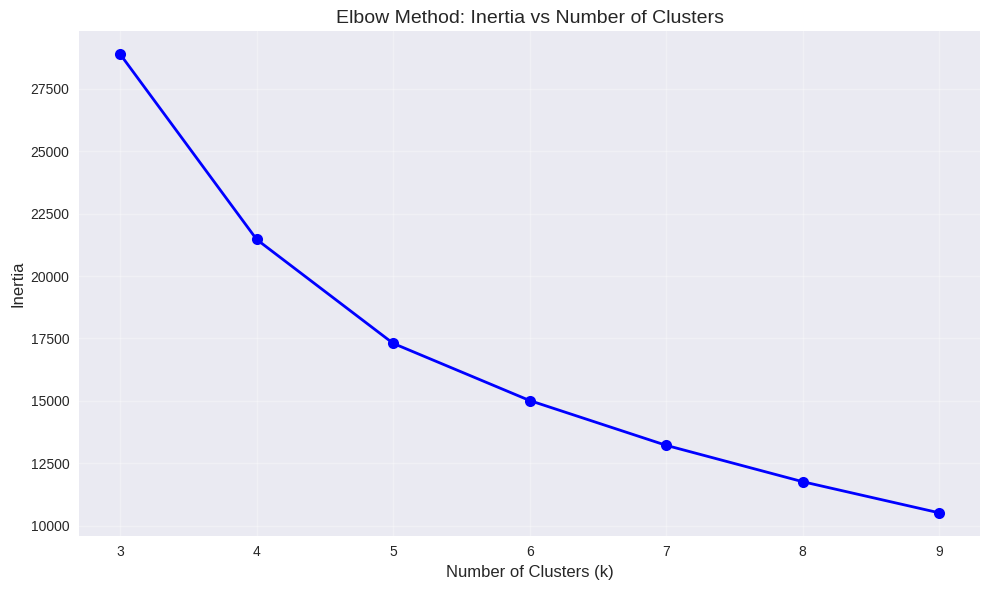

In [23]:
# 2.2 ANSWER: Create Elbow plot

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method: Inertia vs Number of Clusters', fontsize=14)
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Optimal K

optimal_k = 5

**Rationale**: The elbow plot shows a clear inflection point at k=5, where the rate of inertia decrease slows significantly, suggesting diminishing returns from adding more clusters beyond this point.

### 3: Cluster Analysis and Visualization [3 Marks]

#### 3.1 Identify the Cluster Number for Each Order

- Create a K-means model using the four numerical features from `all_orders_df` and the optimal number of clusters identified in Task 2.
- Fit the model on the scaled numerical features.
- Use the fitted model to assign a cluster number to each order and add a new column called `cluster` to `all_orders_df`.
- Show the first 10 rows of `all_orders_df` to verify cluster assignment.


In [24]:
# 3.1 ANSWER: Fit K-means with optimal k and assign clusters
optimal_k = 5
# Scale the numerical features from all_orders_df
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(all_orders_df[numerical_features])

# Fit K-means with the optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=37, n_init=10)
kmeans_final.fit(X_all_scaled)

# Assign cluster labels to all_orders_df
all_orders_df['cluster'] = kmeans_final.labels_

print(f"Cluster distribution:\n{all_orders_df['cluster'].value_counts().sort_index()}")
print(f"\nFirst 10 rows of all_orders_df:")
display(all_orders_df.head(10))


Cluster distribution:
cluster
0    25142
1     5095
2     3072
3    12059
4      919
Name: count, dtype: int64

First 10 rows of all_orders_df:


,order_id,basket_size,basket_qty,freight_ratio,product_diversity,top_product_category,payment_type,order_size_category,cluster
0,sdv-id-whzjUX,744.312535,1,0.092421,1.000000,construction_tools_construction,voucher,Small,0
1,sdv-id-dbopoJ,1556.667902,1,0.009889,1.000000,health_beauty,credit_card,Small,4
2,sdv-id-FSEOvM,62.060506,1,0.302145,1.000000,luggage_accessories,debit_card,Small,3
3,sdv-id-bQcBUR,73.873470,1,0.117375,1.000000,computers_accessories,credit_card,Small,0
4,sdv-id-MPxIXB,361.961537,3,0.095953,1.000000,pet_shop,voucher,Medium,0
5,sdv-id-ySodbB,867.750230,7,0.204442,0.857143,sports_leisure,voucher,Large,2
6,sdv-id-wdwBrk,55.965822,2,0.285101,0.500000,toys,points,Small,1
7,sdv-id-maBYtk,170.295452,3,0.089290,1.000000,computers_accessories,voucher,Medium,0
8,sdv-id-oodUXj,83.065603,1,0.236471,1.000000,furniture_decor,voucher,Small,3
9,sdv-id-zroJIL,98.250248,1,0.369709,1.000000,fashion_bags_accessories,points,Small,3


## Post K-means refit
Now that everything is on a standard scale, K-Means is re-fitted all on 46,287 orders to assign a cluster label to every order.

#### 3.2 Visualize the Clusters

Create two visualizations to understand your clusters:

- **Visualization 1: Cluster Profile Heatmap**
  - Visualize the cluster profiles using a heatmap to understand the average characteristics of each segment.
  - Step 1: Compute the mean of the four numerical features (`basket_size`, `basket_qty`, `freight_ratio`, `product_diversity`) for each cluster.
  - Step 2: Scale these means (e.g., using `StandardScaler` to calculate Z-scores) so that different units (price vs. count) can be compared directly.
  - Step 3: Plot the scaled means as a heatmap:
    - X-axis: Cluster number
    - Y-axis: Feature name
    - Color: Use a diverging colormap (e.g., `RdBu_r`) to distinguish features that are above average (positive Z-score) from those that are below average (negative Z-score)
    - Annotation: Display the Z-score values in each cell
  - Add a clear title.

- **Visualization 2: Cluster Size Distribution**
  - Create a bar chart showing the number of orders in each cluster.
    - X-axis: Cluster number (0, 1, 2, ...)
    - Y-axis: Count of orders
    - This helps you understand if clusters are balanced or if some clusters dominate.
  - Add a title and axis labels.


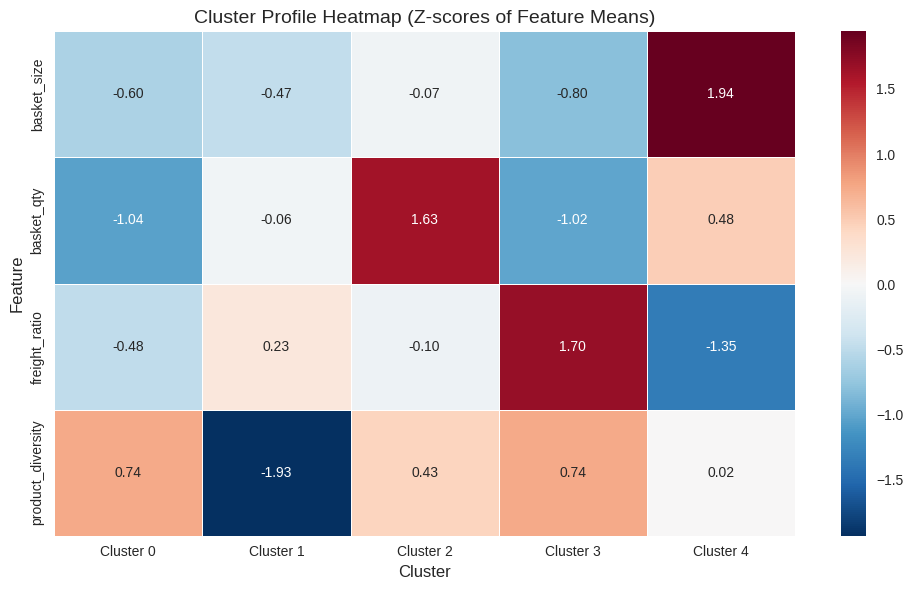

,basket_size,basket_qty,freight_ratio,product_diversity
cluster,,,,
0,188.057448,1.151977,0.120785,1.000000
1,260.399514,2.507949,0.176454,0.452015
2,482.470070,4.847982,0.150922,0.936506
3,78.765959,1.179617,0.289917,0.999433
4,1595.607742,3.262242,0.053789,0.851928


In [25]:
# 3.2 ANSWER: Visualization 1 - Cluster profile heatmap

# Step 1: Compute mean of numerical features per cluster
cluster_means = all_orders_df.groupby('cluster')[numerical_features].mean()

# Step 2: Scale the means using StandardScaler (Z-scores)
scaler_heatmap = StandardScaler()
cluster_means_scaled = pd.DataFrame(
    scaler_heatmap.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

# Step 3: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_means_scaled.T,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    xticklabels=[f'Cluster {i}' for i in cluster_means_scaled.index],
    yticklabels=numerical_features
)
plt.title('Cluster Profile Heatmap (Z-scores of Feature Means)', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

display(cluster_means)


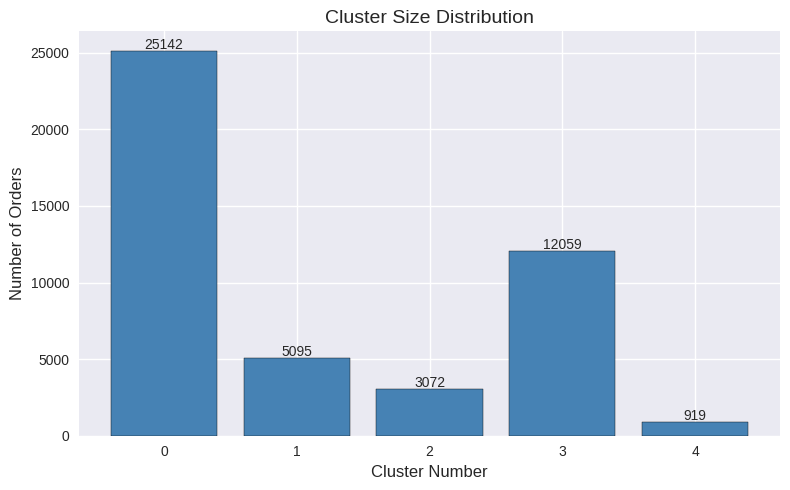

,count
cluster,
0,25142
1,5095
2,3072
3,12059
4,919


In [26]:
# 3.2 ANSWER: Visualization 2 - Cluster size distribution

cluster_counts = all_orders_df['cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Cluster Number', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.title('Cluster Size Distribution', fontsize=14)
plt.xticks(cluster_counts.index)

# Add count labels on top of bars
for i, v in enumerate(cluster_counts.values):
    plt.text(cluster_counts.index[i], v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

display(cluster_counts.to_frame("count"))


**Briefly comment (2-3 sentences) on:**

- How well separated do the clusters appear based on the heatmap?
- Which features seem to have the most significant impact on defining the clusters? Why might this be the case?
- Based on the visualizations that you have generated, comment on the nature of the clusters and what it implies for an e-commerce business



**3.2 ANSWER:**

*[Write your commentary here]*

1) The clusters are well-separated as each cluster shows strong positive and negative Z-scores across different features. These clear contrasts indicate meaningful segmentation rather than overlapping groups.
  - Cluster 1: product_diversity
  - Cluster 0 & 2: basket_qty
  - Cluster 3: freight_ratio
  - Cluster 4: basket_size


2) The most influentaial features appear. to be `basket_size`, `basket_qty`, and `freight_ratio`, as they show the largest magnitude Z-scores across clusters. They reflect the nature of how consumers shop (single cheap items vs. bulk purchases vs. high-value orders).

3) The clusters suggest distinct customer segments:

Cluster 0 (largest group): Smaller baskets (low size and quantity) but relatively diverse products, likely everyday low-value purchases.

Cluster 1: Low diversity baskets which shows customers buying few repeated or similar products.

Cluster 2: High quantity orders (Z = 1.63) which indicates bulk buyers.

Cluster 3: High freight ratio which indicates possibly geographically distant customers or heavy/low-value item purchases.

Cluster 4 (smallest but high-value segment): Very high basket size and low freight ratio, which indicates premium or high-spending customers.


From a business perspective, this segmentation highlights clear opportunities for differentiated strategies:

Basket expansion strategies for Cluster 0: Since this is the largest segment with small but diverse baskets, targeted cross-selling, bundle recommendations, and free-shipping thresholds could increase average order value.

Category-focused retention strategies for Cluster 1: With very low product diversity, these customers show concentrated purchasing behavior. Subscription services, replenishment reminders, and personalized category promotions could strengthen loyalty.

Volume-based promotions for Cluster 2: As high-quantity buyers, this segment is well suited for bulk discounts, tiered pricing, and loyalty incentives that reward larger purchases.

Shipping incentives and logistics optimization for Cluster 3: Given their high freight ratio, offering delivery discounts or minimum-spend free shipping could reduce cost sensitivity and improve conversion.

Premium retention strategies for Cluster 4: As the highest-spending segment, these customers should be prioritized through VIP programs, personalized marketing, and exclusive offers to maximize lifetime value.


### 4: Market Basket Analysis (Association Rule Mining) [8 Marks]

#### 4.1 Context: What is Market Basket Analysis?

Market Basket Analysis is an unsupervised learning technique that identifies which products, categories, or attributes are frequently observed together. In e-commerce, this helps answer questions such as:

- "Which payment methods are preferred for which product categories?"
- "Do certain order sizes correlate with specific product types?"
- "What are the multi-dimensional patterns across category, payment, and order size?"

Association rules are commonly described using three key metrics:

- **Support**: How frequently a pattern occurs (0-1 scale)
- **Confidence**: Likelihood of the consequent given the antecedent (0-1 scale)
- **Lift**: How much more likely the rule is compared to random chance (> 1 indicates a positive association)

The Apriori algorithm discovers frequent itemsets and then generates association rules from them.

In this task, you will perform Market Basket Analysis using the categorical features from `all_orders_df` to discover multi-dimensional associations between product category, payment type, and order size category.


#### 4.2 Prepare Transaction Data [1 Mark]

Convert each order in `all_orders_df` into a simple "basket" representation.

Create a Python list called `transactions`, where each element represents one order and contains exactly three string items constructed from that order:

- `cat_{top_product_category}` (e.g., `cat_electronics`, `cat_furniture_decor`)
- `pay_{payment_type}` (e.g., `pay_credit_card`, `pay_boleto`)
- `size_{order_size_category}` (e.g., `size_Small`, `size_Large`)

After constructing `transactions`, display the first 5 transactions to verify the format.


In [27]:
# 4.2 ANSWER: Create transaction list

transactions = []
for _, row in all_orders_df.iterrows():
    transaction = [
        f"cat_{row['top_product_category']}",
        f"pay_{row['payment_type']}",
        f"size_{row['order_size_category']}"
    ]
    transactions.append(transaction)

# Display first 5 transactions
print("First 5 transactions:")
for i, t in enumerate(transactions[:5]):
    print(f"  Order {i}: {t}")

print(f"\nTotal transactions: {len(transactions)}")


First 5 transactions:
  Order 0: ['cat_construction_tools_construction', 'pay_voucher', 'size_Small']
  Order 1: ['cat_health_beauty', 'pay_credit_card', 'size_Small']
  Order 2: ['cat_luggage_accessories', 'pay_debit_card', 'size_Small']
  Order 3: ['cat_computers_accessories', 'pay_credit_card', 'size_Small']
  Order 4: ['cat_pet_shop', 'pay_voucher', 'size_Medium']

Total transactions: 46287


## Basket/grouping items together
Each order is encoded as a 3-item basket combining product category, payment type, and order size, allowing Apriori to discover associations across these three business-relevant dimensions simultaneously.
Apriori is a classic algorithm in data mining used to find frequent itemsets and generate association rules.

#### 4.3 Encode Transactions and Apply Apriori Algorithm [2 Marks]

Use the `mlxtend` library to discover frequent itemsets and generate association rules.

- Step 1: Encode transactions using `TransactionEncoder` and display the shape of the encoded DataFrame.
- Step 2: Apply `apriori()` with `min_support = 0.01` and `use_colnames = True`, then display the number of frequent itemsets found.
- Step 3: Generate association rules using `association_rules()` with `metric = 'lift'` and `min_threshold = 1.0`, then display the number of rules generated.


In [28]:
# 4.3 ANSWER: Step 1 - Encode transactions

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded DataFrame shape: {te_df.shape}")
print(f"Number of unique items: {len(te.columns_)}")
display(te_df.head())


Encoded DataFrame shape: (46287, 79)
Number of unique items: 79


,cat_agro_industry_and_commerce,cat_air_conditioning,cat_art,cat_arts_and_craftmanship,cat_audio,cat_auto,cat_baby,cat_bed_bath_table,cat_books_general_interest,cat_books_imported,...,cat_toys,cat_watches_gifts,pay_credit_card,pay_debit_card,pay_not_defined,pay_points,pay_voucher,size_Large,size_Medium,size_Small
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [29]:
# 4.3 ANSWER: Step 2 - Apply Apriori

frequent_itemsets = apriori(te_df, min_support=0.01, use_colnames=True)

print(f"Number of frequent itemsets found: {len(frequent_itemsets)}")
display(frequent_itemsets.head(10))


Number of frequent itemsets found: 102


,support,itemsets
0,0.030592,(cat_auto)
1,0.023592,(cat_baby)
2,0.138678,(cat_bed_bath_table)
3,0.073152,(cat_computers_accessories)
4,0.016311,(cat_consoles_games)
5,0.011126,(cat_construction_tools_construction)
6,0.027740,(cat_cool_stuff)
7,0.016916,(cat_electronics)
8,0.030419,(cat_fashion_bags_accessories)
9,0.073736,(cat_furniture_decor)


In [30]:
# 4.3 ANSWER: Step 3 - Generate association rules

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

print(f"Number of association rules generated: {len(rules)}")
display(rules.head())


Number of association rules generated: 138


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(cat_auto),(pay_credit_card),0.030592,0.604641,0.020503,0.670198,1.108423,1.0,0.002006,1.198777,0.100904,0.033352,0.165817,0.352053
1,(pay_credit_card),(cat_auto),0.604641,0.030592,0.020503,0.033909,1.108423,1.0,0.002006,1.003433,0.247414,0.033352,0.003422,0.352053
2,(pay_credit_card),(cat_baby),0.604641,0.023592,0.015015,0.024833,1.052604,1.0,0.000750,1.001273,0.126403,0.024486,0.001271,0.330640
3,(cat_baby),(pay_credit_card),0.023592,0.604641,0.015015,0.636447,1.052604,1.0,0.000750,1.087487,0.051182,0.024486,0.080449,0.330640
4,(size_Small),(cat_baby),0.864735,0.023592,0.020913,0.024184,1.025108,1.0,0.000512,1.000607,0.181074,0.024110,0.000607,0.455316


## Discovering patterns
`min_support=0.01` filters patterns appearing in fewer than 1% of orders (~463), removing rare noise. lift ≥ 1.0 retains only rules where items appear together more than random chance

#### 4.4 Extract and Display Top 10 Rules [1 Mark]

Sort the association rules by **lift** in descending order and display the top 10 rules in a table showing:

- Antecedents (left-hand side of rule)
- Consequents (right-hand side of rule)
- Support
- Confidence
- Lift

Example rule output and interpretation:

| antecedents | consequents | support | confidence | lift |
| :--- | :--- | :--- | :--- | :--- |
| (cat_furniture_decor, size_Large) | (pay_credit_card) | 0.042 | 0.756 | 1.84 |

"Customers who purchase **furniture** in **large orders** have a **75.6% probability** (confidence) of paying with a **credit card**. This behavior is **1.84 times more likely** (lift) than the general probability of using a credit card.


In [31]:
# 4.4 ANSWER: Display top 10 rules by lift

top_10_rules = rules.sort_values('lift', ascending=False).head(10)

# Display a clean table
display(top_10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].reset_index(drop=True))


,antecedents,consequents,support,confidence,lift
0,(cat_furniture_decor),(size_Large),0.014583,0.197773,5.328480
1,(size_Large),(cat_furniture_decor),0.014583,0.392899,5.328480
2,"(size_Medium, pay_credit_card)",(cat_bed_bath_table),0.016851,0.280576,2.023212
3,(cat_bed_bath_table),"(size_Medium, pay_credit_card)",0.016851,0.121514,2.023212
4,(size_Medium),"(cat_bed_bath_table, pay_credit_card)",0.016851,0.171693,1.757439
5,"(cat_bed_bath_table, pay_credit_card)",(size_Medium),0.016851,0.172490,1.757439
6,(size_Medium),(cat_furniture_decor),0.012660,0.128990,1.749354
7,(cat_furniture_decor),(size_Medium),0.012660,0.171696,1.749354
8,(size_Medium),(cat_bed_bath_table),0.022749,0.231785,1.671388
9,(cat_bed_bath_table),(size_Medium),0.022749,0.164044,1.671388


#### 4.5 Interpretation (3-4 sentences) [3 Marks]

Write a brief interpretation explaining:

- What the top 3 unique rules tell you about customer behavior
- Which combinations are most strongly associated (highest lift)
- Why these associations might exist (business intuition)
- Change the min_support value to 0.005 and 0.3 and comment on any changes in the rules identified


**4.5 ANSWER:**

### Top 3
The top three unique rules show that large orders are very strongly associated with furniture and decor purchases (lift = 5.33), and that bed_bath_table products are frequently linked with medium-sized orders paid by credit card (lift ≈ 2.02).

### Highest lift:
Definition of lift:
lift = (how often A and B appear together) / (how often A appears × how often B appears)

The strongest association is between size_Large and cat_furniture_decor, at lift=5.33.

Suggesting 5x more likely over random chance.

### Why these associations might exist (business intuition)
Asides from size, furniture generally cost more to make and purchase, thus high-value product. People tend to buy in sets as well (e.g. buying a bedframe + mattress), pushing up the order size and value.


In [32]:
# Change the min_support value to 0.005 and 0.3 and comment on any changes in the rules identified

# min_support = 0.005
fi_005 = apriori(te_df, min_support=0.005, use_colnames=True)
rules_005 = association_rules(fi_005, metric='lift', min_threshold=1.0)
print(f"\n0.005:\n{len(fi_005)} itemsets, {len(rules_005)} rules\n")

# min_support = 0.3
fi_30 = apriori(te_df, min_support=0.3, use_colnames=True)
rules_30 = association_rules(fi_30, metric='lift', min_threshold=1.0)
print(f"\n0.3:\n{len(fi_30)} itemsets, {len(rules_30)} rules\n")


0.005:
168 itemsets, 280 rules


0.3:
3 itemsets, 2 rules




| min_support |rules |
| --- | --- |
| 0.005 | 280 |
| 0.01 | 138 |
| 0.3 | 2 |

`min_support` means showing the patterns that appear at `min_support` percentage level. 0.005, 0.3 means 0.5%, 30% of all orders respectively. The higher the percentage level, the stricter it is as shown in the table. Only 2 rules survived the 30% threshold, as most patterns are too rare to appear in nearly a third of all orders. Depending on the requirements, we can iteratively figure out the top-K common trends by tuning the `min_support` threshold.


#### 4.6 Business Recommendations (2-3 bullet points) [1 Mark]

Based on the discovered associations, provide actionable business recommendations for an e-commerce firm.


**4.6 ANSWER:**

*[Write your business recommendations here as bullet points]*

- Promote furniture bundles for large orders since furniture_decor and size_Large are strongly associated (lift=5.33). The business should offer bundle deals, installment payment or free delivery for large furniture orders to maximize revenue, encourage higher order values, better value per sale.

- Target bed_bath_table buyers with credit card promotions: Purchases are strongly linked to credit card payments (lift=2.02), partnering with banks to offer cashback can drive more sales.

- Use support thresholds strategically for campaign design: High-support rules (e.g., common purchase patterns) should guide broad marketing campaigns, while lower-support but high-lift niche patterns can be used for targeted, personalized promotions to specific customer segments.

#### Tips

- Rules with **lift > 1.5** are considered strong associations; rules with **lift > 2.0** are very strong.
- When writing interpretations, explain not just the statistical strength but also the **business logic** behind the patterns.

---
## Task: Report (5 Marks)

### Objective

(Note: No separate report submission is required.) The report comprises the write-up that you have been working on within this iPython notebook. The write-up/report should clearly describe the steps performed and the reasoning behind each processing done for all the tasks from Assignment 1 until Association mining above.

### 1: Write-up / Report

Describe the steps performed and the reasoning behind each processing step for all tasks you have worked on so far:

- Assignment 1 (data cleaning and preprocessing)
- Assignment 2 (supervised learning)
- Assignment 3 (unsupervised learning)

Include your explanations inline near the cells where processing is done, and keep your descriptions concise but clear. Connect each analysis step to business objectives where appropriate.


## Assignment 1 — Data Cleaning & Preprocessing

**Load data:**
The cleaned dataset from Assignment 1 (46,287 orders, 17 columns) is loaded. It contains order-level features including pricing, item counts, product category, payment type, and the engineered features order_value_per_item and order_size_category.

**Inner joins:**
An inner join as a common denominator/identifier ensures only orders with complete records across all four tables are retained, avoiding incomplete rows.

**Handle missing values:**
Median imputation is used for avg_item_price as it is robust to outliers. Mode imputation is used for categorical columns (top_product_category, payment_type) since the most frequent value is the best single-point estimate.
Note: top_product_category had 11.56% missing — this level of imputation may inflate bed_bath_table's frequency downstream.

**Invalid records:**
Records with zero or negative num_items or order_total_value are logically impossible for a valid transaction and are removed to ensure data quality.

**Sanity Check:**
These checks enforce 2 rules: an order cannot have more unique products than items, and the total order value must cover item price plus freight. Rows failing these checks likely reflect data entry errors, meaning code above is wrong.

**Bar chart observations:**
1) The top 5 product categories (bed_bath_table, health_beauty, furniture_decor, computers_accessories, telephony) dominate about 43.3% of all the orders, while the remaining 66 categories split the leftover 56.7%.
2) Most other categories have significantly fewer orders, indicating that customer demand is concentrated in a few popular product types rather than evenly spread across all categories.
3) Notably, bed_bath_table alone represents 13.9% of orders (6,419), which may be partially inflated since 11.56% of originally missing category values were imputed with this mode during data cleaning.

**Box plot observations:**
1) Order total value generally increases as the number of items increases, indicating a positive relationship between order size and total spending.
2) However, the presence of many outliers and increasing spread for higher item counts suggests substantial variability in prices, meaning larger orders do not always translate to proportionally higher total values.
3) Outliers appear across all item counts but are most prominent in single-item orders, suggesting high-value individual products can match or exceed multi-item order totals.

---

## Assignment 2 — Supervised Learning

**Test dataset:**
Using a test dataset is crucial for evaluating the true performance of a machine learning model. It provides an unbiased assessment of how well the model generalizes to new, unseen data. Without a separate test set, a model's performance might be overestimated, as it could have simply memorized the training data (overfitting). By holding out a portion of the data for testing, we can gauge the model's ability to predict outcomes on data it has not encountered during training, ensuring its reliability for real-world applications.

**Categorical encoding:**
Categorical encoding is needed because most machine learning models only understand numbers and cannot directly interpret text labels. Encoding converts text categories into numerical representations, such as integers (Label Encoding) or binary vectors (One-Hot Encoding), so models can process them. This allows models to learn patterns and relationships within the data, leading to effective predictions.

**Feature scaling:**
Feature scaling is important because it prevents features with larger numerical values from disproportionately influencing model training. By bringing all features to a similar scale, it ensures that every feature contributes equally to the learning process, leading to more stable and effective model performance.

**Model strengths and weaknesses:**
Logistic Regression — Strengths: Simple, interpretable, computationally efficient, good baseline, performs well when class boundaries are approximately linear and features are well-scaled. Provides probability scores. Weaknesses: Assumes linearity, may not capture complex relationships, sensitive to outliers and multicollinearity.
Decision Tree — Strengths: Easy to understand and interpret (especially small trees), handles non-linear relationships, requires little data preprocessing. Weaknesses: Prone to overfitting, sensitive to small variations in data, can create biased trees if classes are imbalanced.
Random Forest — Strengths: Reduces overfitting compared to single decision trees, handles non-linear data well, provides good feature importance, generally high accuracy. Weaknesses: Less interpretable, can be computationally intensive for very large datasets.
Impact of Class Imbalance Handling: If class imbalance is not handled, models might be biased towards the majority class, leading to high accuracy but poor performance on the minority class. Metrics like precision, recall, and F1-score (especially 'weighted' averages) are more informative than accuracy in the presence of class imbalance.

**Model selection — Random Forest:**
The Random Forest model achieved the highest Accuracy (0.626), highest Precision (0.577), highest Recall (0.626), and highest F1-Score (0.584) among the three models. Although explicit class imbalance handling techniques were not applied, the Random Forest model's ensemble nature inherently helps by training diverse trees on bootstrapped samples. Random Forest models are generally robust, handle various data types well, and are less prone to overfitting than single decision trees.

**Model interpretability:**
Logistic Regression is highly predictable and is also considered a white box model. Each feature gets a weight (coefficient) that directly shows how much and in what direction it influences the prediction.
Decision Trees are interpretable based on the depth of the tree. The decision rules from root to leaf node help understand how a prediction is made. However, as trees grow deeper, interpretability decreases.
Random Forest is an ensemble of many Decision Trees. Combining hundreds of trees makes the overall model a 'black-box'. We can extract feature importances, which tell us which features were most influential on average across all trees.

**Conclusion:**
This assignment applied supervised learning to predict payment_type. Data Preparation focused on splitting data, categorical encoding, and numerical scaling to prepare features for modeling. The Random Forest model consistently outperformed others across all metrics, particularly the F1-Score, demonstrating its superior predictive power for this task. Random Forest was selected due to its superior predictive performance and robustness to non-linear relationships, making it more suitable for capturing complex interactions between product categories, order value, and payment behaviour.

---

## Assignment 3 — Unsupervised Learning

**Load data:**
Load the cleaned and processed dataset from Assignment 1 (46,287 orders, 17 columns) is loaded with engineered features (order_value_per_item, order_size_category).

**Further feature engineering:**
These four features capture an order's monetary value, volume, shipping cost proportion, and product variety. Division-by-zero is handled explicitly before computing ratios.

**Stratified sampling for Elbow method testing:**
`orders_analysis_df` (30% of all orders) provides a representative random sample to run the Elbow Method (k=3 to 9) without repeatedly fitting K-Means on all 46,287 orders. The full `all_orders_df` is then used in Task 3 to assign every order a final cluster.

**StandardScaler for K-Means to reduce bias:**
StandardScaler is applied before K-Means because the algorithm is distance-based. Without scaling, basket_size (hundreds of dollars) would dominate freight_ratio (0–1 range), producing biased clusters.

**Optimal K:**
The elbow plot shows a clear inflection point at k=5, where the rate of inertia decrease slows significantly, suggesting diminishing returns from adding more clusters beyond this point.

**Post K-Means refit:**
Now that everything is on a standard scale, K-Means is re-fitted on all 46,287 orders to assign a cluster label to every order.

**Cluster analysis:**
1) The clusters are well-separated because they each have at least 1 Z-score that is far from 0, representing a defining feature for each cluster.
  - Cluster 1: product_diversity
  - Cluster 0 & 2: basket_qty
  - Cluster 3: freight_ratio
  - Cluster 4: basket_size
2) `basket_size`, `basket_qty`, and `freight_ratio` reflecting the nature of how consumers shop (single cheap items vs. bulk purchases vs. high-value orders).
3) The heavily skewed cluster sizes (Cluster 0 at 54%) suggest the business should focus mass marketing on everyday buyers, bundle deals for repeat low-variety buyers (Cluster 1), bulk discounts for Cluster 2, shipping incentives for Cluster 3, and premium loyalty programmes for high-value customers (Cluster 4).

**Basket/grouping items together:**
Each order is encoded as a 3-item basket combining product category, payment type, and order size, allowing Apriori to discover associations across these three business-relevant dimensions simultaneously. Apriori is a classic algorithm in data mining used to find frequent itemsets and generate association rules.

**Discovering patterns:**
`min_support=0.01` filters patterns appearing in fewer than 1% of orders (~463), removing rare noise. lift ≥ 1.0 retains only rules where items appear together more than random chance.

**Top 3 association rules:**
1. furniture_decor: Furniture_decor orders are strongly associated with large order sizes; furniture generally big and bulky, costs more.
2. bed_bath_table: Bed_bath_table customers paying by credit card tend to be medium-sized orders.
3. size_Medium: Medium orders are associated with credit card payments generally from bed_bath_table.
Highest lift: furniture_decor & size_Large at lift=5.33, suggesting 5x more likely over random chance.
Why these associations might exist: Furniture generally costs more to make and purchase, thus high-value product. People tend to buy in sets as well (e.g. buying a bedframe + mattress), pushing up the order size and value.

**min_support:**
| min_support | rules |
| --- | --- |
| 0.005 | 280 |
| 0.01 | 138 |
| 0.3 | 2 |

min_support represents the proportion of total orders in which a pattern must appear to be considered frequent. 0.005, 0.3 means 0.5%, 30% of all orders respectively. The higher the percentage level, the stricter it is as shown in the table. Only 2 rules survived the 30% threshold, as most patterns are too rare to appear in nearly a third of all orders. Depending on the requirements, we can iteratively figure out the top-K common trends by tuning the `min_support` threshold.

**Business recommendations:**
- Promote furniture bundles for large orders since furniture_decor and size_Large are strongly associated (lift=5.33). The business should offer bundle deals or free delivery for large furniture orders to encourage higher order values, better value per sale.
- Target bed_bath_table buyers with credit card promotions: Purchases are strongly linked to credit card payments (lift=2.02), partnering with banks to offer cashback can drive more sales.


# Connecting to business objectives

**Assignment 1 — Data quality for reliable decisions:**
Having clean, reliable data is crucial before we can make any analysis and then business decisions. Removing invalid records and imputing missing values, the 46,287-order dataset aims to achieve that objective.

The bar chart reveals demand is concentrated in a few categories (top 5 = 43.3% of orders), this guides business on where to focus their resources; inventory and marketing. The positive relationship between order size and value (box plot) supports tiered pricing and bundle strategies.

**Assignment 2 — Predicting payment behaviour:**
Predicting `payment_type` with Random Forest (F1=0.584) enables the business to anticipate how customers will pay before checkout. This supports payment-specific promotions (e.g., credit card cashback, voucher campaigns). Further, this can relate to the underlying payment infrastructure that has to be procured and how the engineers have to design and build the system, min-maxing the tech stack.

**Assignment 3 — Segmenting customers and uncovering purchasing patterns:**
Clustering reveals 5 distinct order profiles each requiring a different marketing approach. Association rules further show that relationship between traits of each purchase. Such as furniture_decor strongly co-occurs with large order sizes (lift=5.33) and bed_bath_table purchases are linked to credit card payments (lift=2.02). This allows sales and marketing to strategise targeted bundle promotions and bank partnership deals.

**Limitations**

1) Mode imputation for top_product_category (11.56% missing) may inflate the frequency of bed_bath_table, potentially influencing clustering and association results.

2) K-Means assumes spherical clusters and equal variance, which may oversimplify real purchasing behavior.

3) Association rules identify correlation, not causation.

4) Support threshold selection affects rule discovery and business interpretation.

**Future Improvements**

1) Apply silhouette score or Davies–Bouldin index to further validate optimal k.

2) Experiment with hierarchical clustering to compare segmentation stability.

3) Incorporate customer-level data (e.g., repeat purchases) for deeper behavioural insights.

**Overall**
Assignment 1 cleans and prepares the data. Assignment 2 predicts the individuals behaviour. Assignment 3 helps to discover patterns. Together, these three analytical approaches transform raw transactional data into actionable business intelligence - enabling predictive capability, customer segmentation, targeted promotions, logistics optimisation, and ultimately improved revenue and profitability.

---
### 2: Publish the Report

Publish the report as a read-only github.io static page.

- Note: this differs from setting up a GitHub repository with your iPython notebook in it.
- Convert your notebook to HTML and host it on GitHub Pages (e.g., using nbconvert or Jupyter Book).

Ensure the page is publicly accessible and provide the URL in your Canvas submission.

**Your published URL:**

*https://chongjinisnotavailableisavailable.github.io/it5100f-AY2526-project-Grp11/*


---
# End of Assignment 3

**Before submission, ensure:**
1. All code cells execute without errors
2. All markdown cells contain your written explanations
3. Visualizations are clear and properly labeled
4. Your notebook tells a coherent story from start to finish
5. Your github.io page is published and URL is provided

**Good luck!**